In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re

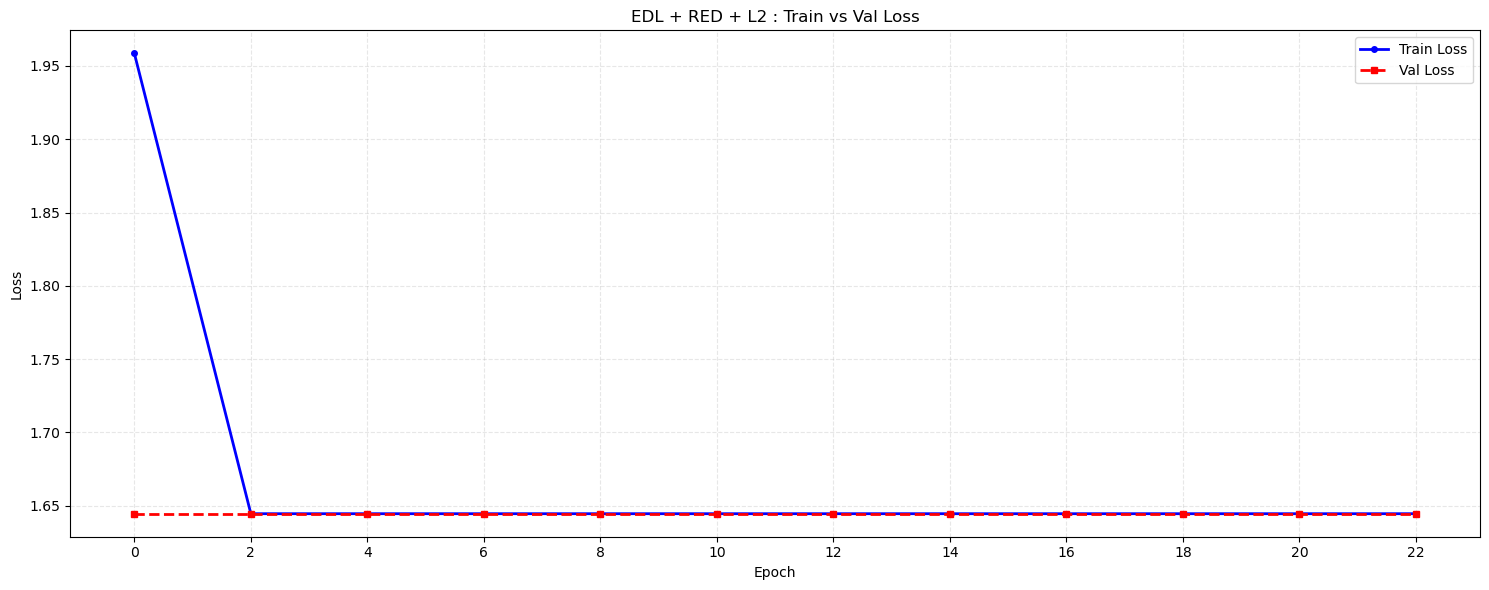

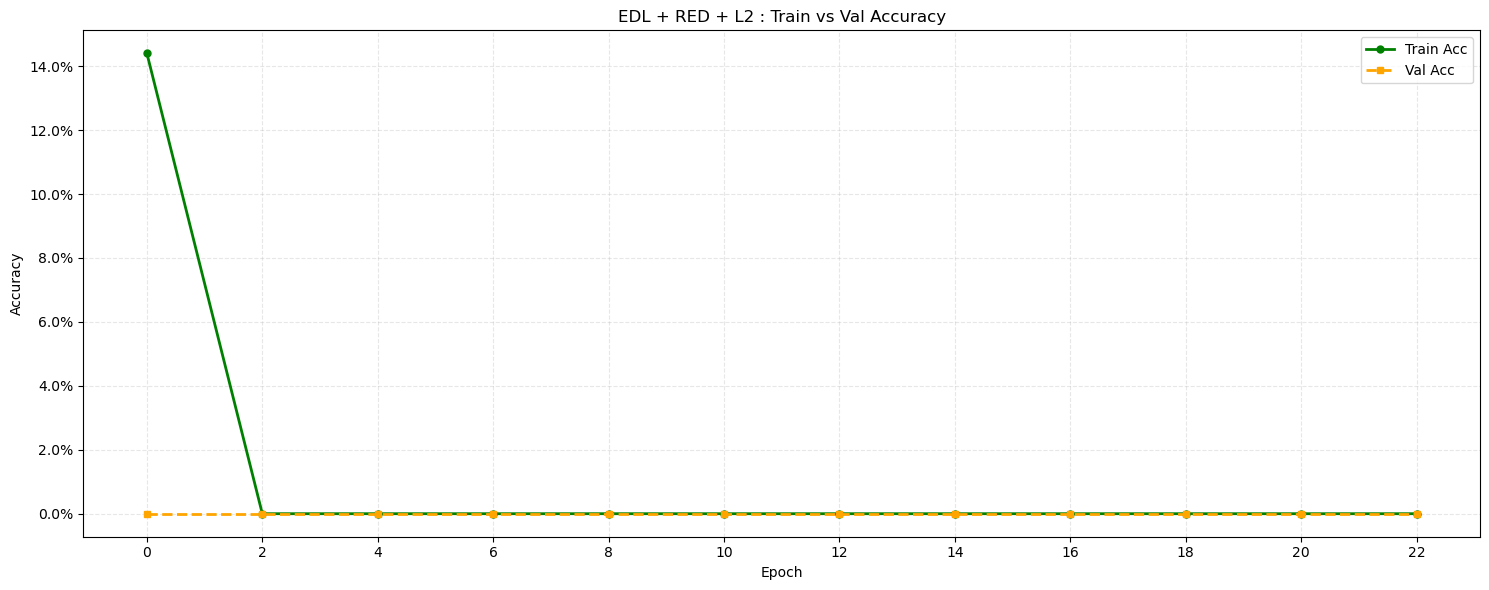

In [2]:

def load_softmax_history(path="edl_loss_history.txt"):
    with open(path, "r") as f:
        content = f.read()

    pattern = (
        r"Epoch\s+(\d+)\s+-\s+Train Loss:\s*([\d.]+),\s+Train Acc:\s*([\d.]+),\s+"
        r"Val Loss:\s*([\d.]+),\s+Val Acc:\s*([\d.]+)"
    )
    matches = re.findall(pattern, content)

    epochs     = [int(m[0])   for m in matches]
    train_loss = [float(m[1]) for m in matches]
    train_acc  = [float(m[2]) for m in matches]
    val_loss   = [float(m[3]) for m in matches]
    val_acc    = [float(m[4]) for m in matches]

    return epochs, train_loss, val_loss, train_acc, val_acc

def plot_softmax_loss():
    epochs, train_loss, val_loss, _, _ = load_softmax_history()

    step = 2 # Show every 30 epochs

    plt.figure(figsize=(15,6))
    plt.plot(epochs[::step], train_loss[::step], "b-o", label="Train Loss",  linewidth=2, markersize=4)
    plt.plot(epochs[::step], val_loss[::step],   "r--s", label="Val Loss",    linewidth=2, markersize=4)
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("EDL + RED + L2 : Train vs Val Loss")
    plt.grid(True, alpha=0.3, linestyle="--")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_softmax_accuracy():
    epochs, _, _, train_acc, val_acc = load_softmax_history()

    step = 2  # Show every 30 epochs

    plt.figure(figsize=(15,6))
    plt.plot(epochs[::step], train_acc[::step], "g-o", label="Train Acc", linewidth=2, markersize=5)
    plt.plot(epochs[::step], val_acc[::step], "orange", linestyle="--", marker="s", label="Val Acc", linewidth=2, markersize=5)
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
    plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("EDL + RED + L2 : Train vs Val Accuracy")
    plt.grid(True, alpha=0.3, linestyle="--")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Call these:
plot_softmax_loss()
plot_softmax_accuracy()